# Machine Learning - Previsão por Categoria Criminal

Este notebook treina e avalia modelos para prever taxas criminais por 100 mil habitantes nas capitais brasileiras.

Fonte oficial:

`datamart.vw_indicadores_municipio_ano`

Estratégia metodológica:

- **Linear Regression**: baseline simples e interpretável.
- **Random Forest Regressor**: modelo principal candidato, capaz de capturar relações não lineares.

O objetivo é comparar o desempenho dos modelos para a taxa geral de crimes e para categorias específicas, como homicídios, estupros, furto/roubo de veículos, feminicídios e mortes violentas intencionais.

## 1. Imports

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sqlalchemy import create_engine

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')

## 2. Conexão com o PostgreSQL

Dentro do Docker Compose, o host do PostgreSQL é `postgres-service`.

Se o notebook for executado fora do container, altere `POSTGRES_HOST` para `localhost`.

In [2]:
DB_USER = os.getenv('POSTGRES_USER', 'postgres')
DB_PASSWORD = os.getenv('POSTGRES_PASSWORD', 'postgres')
DB_HOST = os.getenv('POSTGRES_HOST', 'postgres-service')
DB_PORT = os.getenv('POSTGRES_PORT', '5432')
DB_NAME = os.getenv('POSTGRES_DB', 'seguranca_publica')

engine = create_engine(
    f'postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
)

## 3. Carregar base analítica

Usamos a view executiva do Data Mart porque ela contém as taxas gerais, categorias criminais, dados socioeconômicos, população e educação.

In [3]:
query = """
SELECT *
FROM datamart.vw_indicadores_municipio_ano
ORDER BY codigo_municipio, ano;
"""

df_raw = pd.read_sql(query, engine)
df_raw.head()

,id_fato_municipio_ano_dw,ano,decada,periodo_analise,codigo_municipio,nome_municipio,nome_municipio_padronizado,codigo_uf_ibge,sigla_uf,nome_uf,...,taxa_mortes_violentas_100k,taxa_homicidios_100k,taxa_feminicidios_100k,taxa_estupros_100k,taxa_furto_veiculos_100k,risco_indice,classificacao_risco,ranking_risco_ano,ranking_taxa_crimes_ano,ranking_homicidios_ano
0,1,2016,2010,Periodo de analise,1100205,Porto Velho,porto velho,11,RO,Rondonia,...,38.254091,34.648994,NaN,76.508183,373.928735,0.622802,Risco medio,4,1,15
1,2,2017,2010,Periodo de analise,1100205,Porto Velho,porto velho,11,RO,Rondonia,...,31.021572,29.843537,NaN,69.700367,365.190655,0.544321,Risco medio,9,1,17
2,3,2018,2010,Periodo de analise,1100205,Porto Velho,porto velho,11,RO,Rondonia,...,30.797007,29.257157,0.769925,68.330860,358.015210,0.487566,Risco moderado,6,2,15
3,4,2019,2010,Periodo de analise,1100205,Porto Velho,porto velho,11,RO,Rondonia,...,22.472165,19.828381,0.188842,65.150394,375.983865,0.356798,Risco moderado,7,1,16
4,5,2020,2020,Periodo de analise,1100205,Porto Velho,porto velho,11,RO,Rondonia,...,29.850525,26.142385,0.927035,52.840991,NaN,0.443992,Risco moderado,5,27,12


## 4. Diagnóstico inicial

In [4]:
display(df_raw.shape)
display(df_raw.dtypes)
display(df_raw.isna().sum().sort_values(ascending=False).head(30))
display(df_raw.groupby('ano').size().rename('qtd_linhas'))

(243, 46)

id_fato_municipio_ano_dw           int64
ano                                int64
decada                             int64
periodo_analise                   object
codigo_municipio                   int64
nome_municipio                    object
nome_municipio_padronizado        object
codigo_uf_ibge                     int64
sigla_uf                          object
nome_uf                           object
nome_regiao                       object
ciclo_id                          object
descricao_ciclo                   object
dependencia_id                   float64
descricao_dependencia             object
populacao_total                  float64
populacao_crescimento_pct        float64
idhm                             float64
idhm_renda                       float64
idhm_educacao                    float64
idhm_longevidade                 float64
ano_referencia_idhm                int64
ideb                             float64
fluxo                            float64
aprendizado     

crimes_total_indicadores         141
taxa_crimes_100k                 141
ciclo_id                         136
nota_lp                          136
nota_mt                          136
aprendizado                      136
ideb                             136
dependencia_id                   136
descricao_ciclo                  136
fluxo                            136
descricao_dependencia            136
taxa_furto_veiculos_100k          89
roubo_veiculos                    89
furto_veiculos                    89
taxa_estupros_100k                83
estupros                          83
taxa_feminicidios_100k            56
feminicidios                      56
populacao_crescimento_pct         27
mortes_violentas_intencionais      0
latrocinios                        0
taxa_homicidios_100k               0
risco_indice                       0
homicidios_dolosos                 0
classificacao_risco                0
ranking_risco_ano                  0
ranking_taxa_crimes_ano            0
t

ano
2016    27
2017    27
2018    27
2019    27
2020    27
2021    27
2022    27
2023    27
2024    27
Name: qtd_linhas, dtype: int64

## 5. Preparação da base

Como o IDEB não é divulgado todos os anos, usamos `forward fill` por UF para propagar o último valor educacional conhecido.

Isso não usa informação futura: cada ano recebe apenas o último valor disponível até aquele momento.

In [5]:
df = df_raw.copy()
df = df.sort_values(['codigo_municipio', 'ano']).reset_index(drop=True)

colunas_numericas = [
    'ano',
    'populacao_total',
    'populacao_crescimento_pct',
    'idhm',
    'idhm_renda',
    'idhm_educacao',
    'idhm_longevidade',
    'ideb',
    'fluxo',
    'aprendizado',
    'nota_mt',
    'nota_lp',
    'crimes_total_indicadores',
    'mortes_violentas_intencionais',
    'homicidios_dolosos',
    'feminicidios',
    'estupros',
    'furto_veiculos',
    'roubo_veiculos',
    'latrocinios',
    'taxa_crimes_100k',
    'taxa_mortes_violentas_100k',
    'taxa_homicidios_100k',
    'taxa_feminicidios_100k',
    'taxa_estupros_100k',
    'taxa_furto_veiculos_100k',
    'risco_indice',
]

for coluna in colunas_numericas:
    if coluna in df.columns:
        df[coluna] = pd.to_numeric(df[coluna], errors='coerce')

# A taxa de roubo de veículos é calculada aqui porque a fato consolidada guarda a contagem, mas não a taxa pronta.
df['taxa_roubo_veiculos_100k'] = (df['roubo_veiculos'] / df['populacao_total']) * 100000

colunas_educacao = ['ideb', 'fluxo', 'aprendizado', 'nota_mt', 'nota_lp']

for coluna in colunas_educacao:
    df[f'{coluna}_preenchido'] = df.groupby('sigla_uf')[coluna].ffill()

df[['ano', 'sigla_uf', 'ideb', 'ideb_preenchido']].head(12)

,ano,sigla_uf,ideb,ideb_preenchido
0,2016,RO,NaN,NaN
1,2017,RO,4.0,4.0
2,2018,RO,NaN,4.0
3,2019,RO,4.3,4.3
4,2020,RO,NaN,4.3
5,2021,RO,4.1,4.1
6,2022,RO,NaN,4.1
7,2023,RO,4.2,4.2
8,2024,RO,NaN,4.2
9,2016,AC,NaN,NaN


## 6. Definição dos targets por categoria

A modelagem passa a considerar múltiplos alvos criminais. Cada target será treinado separadamente, porque cada categoria tem escala, cobertura e comportamento próprios.

In [6]:
targets_criminais = {
    'Taxa geral de crimes': 'taxa_crimes_100k',
    'Mortes violentas intencionais': 'taxa_mortes_violentas_100k',
    'Homicídios dolosos': 'taxa_homicidios_100k',
    'Feminicídios': 'taxa_feminicidios_100k',
    'Estupros': 'taxa_estupros_100k',
    'Furto de veículos': 'taxa_furto_veiculos_100k',
    'Roubo de veículos': 'taxa_roubo_veiculos_100k',
}

for coluna_target in targets_criminais.values():
    df[f'{coluna_target}_lag1'] = df.groupby('codigo_municipio')[coluna_target].shift(1)

df['risco_indice_lag1'] = df.groupby('codigo_municipio')['risco_indice'].shift(1)

features_base = [
    'ano',
    'populacao_total',
    'populacao_crescimento_pct',
    'idhm',
    'idhm_renda',
    'idhm_educacao',
    'idhm_longevidade',
    'risco_indice_lag1',
    'ideb_preenchido',
    'fluxo_preenchido',
    'aprendizado_preenchido',
    'nota_mt_preenchido',
    'nota_lp_preenchido',
]

colunas_identificacao = ['ano', 'codigo_municipio', 'nome_municipio', 'sigla_uf', 'nome_regiao']

targets_criminais

{'Taxa geral de crimes': 'taxa_crimes_100k',
 'Mortes violentas intencionais': 'taxa_mortes_violentas_100k',
 'Homicídios dolosos': 'taxa_homicidios_100k',
 'Feminicídios': 'taxa_feminicidios_100k',
 'Estupros': 'taxa_estupros_100k',
 'Furto de veículos': 'taxa_furto_veiculos_100k',
 'Roubo de veículos': 'taxa_roubo_veiculos_100k'}

## 7. Cobertura dos targets

Antes de treinar, avaliamos em quais anos cada categoria possui dados. Isso é essencial porque algumas categorias pós-pandemia não estão disponíveis em nível de capital.

In [7]:
cobertura_targets = []

for nome_target, coluna_target in targets_criminais.items():
    cobertura = (
        df.groupby('ano')[coluna_target]
        .apply(lambda serie: serie.notna().sum())
        .reset_index(name='qtd_capitais_com_dado')
    )
    cobertura['target'] = nome_target
    cobertura_targets.append(cobertura)

cobertura_targets = pd.concat(cobertura_targets, ignore_index=True)
cobertura_targets.pivot(index='ano', columns='target', values='qtd_capitais_com_dado')

target,Estupros,Feminicídios,Furto de veículos,Homicídios dolosos,Mortes violentas intencionais,Roubo de veículos,Taxa geral de crimes
ano,,,,,,,
2016,26,0,24,27,27,24,0
2017,27,0,25,27,27,25,0
2018,27,25,26,27,27,26,24
2019,27,27,27,27,27,27,27
2020,27,27,26,27,27,26,26
2021,26,27,26,27,27,26,25
2022,0,27,0,27,27,0,0
2023,0,27,0,27,27,0,0
2024,0,27,0,27,27,0,0


## 8. Split temporal

Plano preferencial com a base atual:

- Treino: 2017, 2018 e 2019
- Teste: 2023 e 2024
- Excluir: 2020, 2021 e 2022

Quando uma categoria não possui dados suficientes nesse split, o notebook usa uma divisão temporal alternativa com os anos disponíveis. Se ainda assim não houver dados mínimos, a categoria é marcada como insuficiente.

In [8]:
anos_treino_planejado = [2017, 2018, 2019]
anos_teste_planejado = [2023, 2024]
anos_excluir = [2020, 2021, 2022]

def escolher_split_temporal(df_modelo, features, target):
    colunas_modelo = list(dict.fromkeys(colunas_identificacao + features + [target]))
    dados = df_modelo[colunas_modelo].dropna().copy()
    anos_disponiveis = set(dados['ano'].astype(int).unique())

    tem_split_planejado = (
        set(anos_treino_planejado).issubset(anos_disponiveis)
        and len(set(anos_teste_planejado).intersection(anos_disponiveis)) > 0
    )

    if tem_split_planejado:
        treino = dados[dados['ano'].isin(anos_treino_planejado)].copy()
        teste = dados[dados['ano'].isin(anos_teste_planejado)].copy()
        estrategia = 'split_planejado_pos_pandemia'
    else:
        dados_sem_anos_excluidos = dados[~dados['ano'].isin(anos_excluir)].copy()
        anos_validos = sorted(dados_sem_anos_excluidos['ano'].astype(int).unique())

        if len(anos_validos) >= 3:
            ano_teste = anos_validos[-1]
            treino = dados_sem_anos_excluidos[dados_sem_anos_excluidos['ano'] < ano_teste].copy()
            teste = dados_sem_anos_excluidos[dados_sem_anos_excluidos['ano'] == ano_teste].copy()
            estrategia = f'fallback_temporal_teste_{ano_teste}'
        else:
            anos_validos = sorted(dados['ano'].astype(int).unique())

            if len(anos_validos) >= 3:
                ano_teste = anos_validos[-1]
                treino = dados[dados['ano'] < ano_teste].copy()
                teste = dados[dados['ano'] == ano_teste].copy()
                estrategia = f'fallback_com_pandemia_teste_{ano_teste}'
            else:
                treino = pd.DataFrame()
                teste = pd.DataFrame()
                estrategia = 'dados_insuficientes'

    return treino, teste, estrategia

## 9. Funções de treino e avaliação

In [9]:
def treinar_e_avaliar(nome_modelo, nome_target, estimador, treino, teste, features, target, usar_scaler=True):
    X_train = treino[features]
    y_train = treino[target]
    X_test = teste[features]
    y_test = teste[target]

    etapas = []
    if usar_scaler:
        etapas.append(('scaler', StandardScaler()))
    etapas.append(('model', estimador))

    pipeline = Pipeline(etapas)
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    previsoes_negativas = int((y_pred < 0).sum())

    metricas = {
        'target': nome_target,
        'modelo': nome_modelo,
        'mae': mean_absolute_error(y_test, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_test, y_pred)),
        'r2': r2_score(y_test, y_pred) if len(y_test) > 1 else np.nan,
        'previsoes_negativas': previsoes_negativas,
        'linhas_treino': len(treino),
        'linhas_teste': len(teste),
    }

    previsoes = teste[colunas_identificacao].copy()
    previsoes['target'] = nome_target
    previsoes['modelo'] = nome_modelo
    previsoes['valor_real'] = y_test.values
    previsoes['valor_previsto'] = y_pred
    previsoes['residuo'] = previsoes['valor_real'] - previsoes['valor_previsto']
    previsoes['erro_absoluto'] = previsoes['residuo'].abs()

    modelo = pipeline.named_steps['model']
    if hasattr(modelo, 'coef_'):
        importancias = pd.DataFrame({
            'target': nome_target,
            'modelo': nome_modelo,
            'feature': features,
            'tipo_importancia': 'coeficiente',
            'valor': modelo.coef_,
        }).sort_values('valor', ascending=False)
    elif hasattr(modelo, 'feature_importances_'):
        importancias = pd.DataFrame({
            'target': nome_target,
            'modelo': nome_modelo,
            'feature': features,
            'tipo_importancia': 'feature_importance',
            'valor': modelo.feature_importances_,
        }).sort_values('valor', ascending=False)
    else:
        importancias = pd.DataFrame(columns=['target', 'modelo', 'feature', 'tipo_importancia', 'valor'])

    return pipeline, metricas, previsoes, importancias

## 10. Treinamento por categoria criminal

Para cada target, treinamos dois modelos:

- Regressão Linear como baseline.
- Random Forest como modelo principal candidato.

In [10]:
modelos_treinados = {}
metricas_lista = []
previsoes_lista = []
importancias_lista = []
splits_lista = []

for nome_target, coluna_target in targets_criminais.items():
    lag_target = f'{coluna_target}_lag1'
    features_target = features_base + [lag_target]

    treino_target, teste_target, estrategia = escolher_split_temporal(df, features_target, coluna_target)

    splits_lista.append({
        'target': nome_target,
        'coluna_target': coluna_target,
        'estrategia': estrategia,
        'anos_treino': sorted(treino_target['ano'].unique()) if not treino_target.empty else [],
        'anos_teste': sorted(teste_target['ano'].unique()) if not teste_target.empty else [],
        'linhas_treino': len(treino_target),
        'linhas_teste': len(teste_target),
    })

    if treino_target.empty or teste_target.empty:
        continue

    modelos = [
        ('Regressao Linear', LinearRegression(), True),
        (
            'Random Forest',
            RandomForestRegressor(
                n_estimators=500,
                max_depth=4,
                min_samples_leaf=3,
                random_state=42,
            ),
            False,
        ),
    ]

    for nome_modelo, estimador, usar_scaler in modelos:
        modelo, metricas, previsoes, importancias = treinar_e_avaliar(
            nome_modelo=nome_modelo,
            nome_target=nome_target,
            estimador=estimador,
            treino=treino_target,
            teste=teste_target,
            features=features_target,
            target=coluna_target,
            usar_scaler=usar_scaler,
        )

        modelos_treinados[(nome_target, nome_modelo)] = modelo
        metricas_lista.append(metricas)
        previsoes_lista.append(previsoes)
        importancias_lista.append(importancias)

splits_modelagem = pd.DataFrame(splits_lista)
metricas_modelos = pd.DataFrame(metricas_lista)
previsoes_modelos = pd.concat(previsoes_lista, ignore_index=True) if previsoes_lista else pd.DataFrame()
importancias_modelos = pd.concat(importancias_lista, ignore_index=True) if importancias_lista else pd.DataFrame()

splits_modelagem

,target,coluna_target,estrategia,anos_treino,anos_teste,linhas_treino,linhas_teste
0,Taxa geral de crimes,taxa_crimes_100k,fallback_com_pandemia_teste_2021,"[2019, 2020]",[2021],50,25
1,Mortes violentas intencionais,taxa_mortes_violentas_100k,split_planejado_pos_pandemia,"[2017, 2018, 2019]","[2023, 2024]",81,54
2,Homicídios dolosos,taxa_homicidios_100k,split_planejado_pos_pandemia,"[2017, 2018, 2019]","[2023, 2024]",81,54
3,Feminicídios,taxa_feminicidios_100k,fallback_temporal_teste_2024,"[2019, 2023]",[2024],52,27
4,Estupros,taxa_estupros_100k,fallback_temporal_teste_2019,"[2017, 2018]",[2019],53,27
5,Furto de veículos,taxa_furto_veiculos_100k,fallback_temporal_teste_2019,"[2017, 2018]",[2019],49,26
6,Roubo de veículos,taxa_roubo_veiculos_100k,fallback_temporal_teste_2019,"[2017, 2018]",[2019],49,26


## 11. Comparação das métricas por categoria

In [11]:
metricas_modelos.sort_values(['target', 'rmse'])

,target,modelo,mae,rmse,r2,previsoes_negativas,linhas_treino,linhas_teste
9,Estupros,Random Forest,7.485704,10.570007,0.581720,0,53,27
8,Estupros,Regressao Linear,9.925300,13.527125,0.314941,0,53,27
7,Feminicídios,Random Forest,0.254648,0.328801,-0.007663,0,52,27
6,Feminicídios,Regressao Linear,0.300971,0.395392,-0.457151,0,52,27
11,Furto de veículos,Random Forest,20.595301,27.053442,0.892773,0,49,26
10,Furto de veículos,Regressao Linear,61.936274,71.756075,0.245647,0,49,26
5,Homicídios dolosos,Random Forest,4.613940,5.667232,0.705940,0,81,54
4,Homicídios dolosos,Regressao Linear,130.356083,155.309301,-219.845476,28,81,54
3,Mortes violentas intencionais,Random Forest,5.077408,6.712151,0.718502,0,81,54
2,Mortes violentas intencionais,Regressao Linear,144.237276,172.006939,-183.860531,28,81,54


## 12. Melhor modelo por categoria

In [12]:
melhores_modelos = (
    metricas_modelos
    .sort_values(['target', 'rmse'])
    .groupby('target')
    .head(1)
    .reset_index(drop=True)
)

melhores_modelos

,target,modelo,mae,rmse,r2,previsoes_negativas,linhas_treino,linhas_teste
0,Estupros,Random Forest,7.485704,10.570007,0.581720,0,53,27
1,Feminicídios,Random Forest,0.254648,0.328801,-0.007663,0,52,27
2,Furto de veículos,Random Forest,20.595301,27.053442,0.892773,0,49,26
3,Homicídios dolosos,Random Forest,4.613940,5.667232,0.705940,0,81,54
4,Mortes violentas intencionais,Random Forest,5.077408,6.712151,0.718502,0,81,54
5,Roubo de veículos,Random Forest,40.707072,51.883807,0.730594,0,49,26
6,Taxa geral de crimes,Random Forest,38.451029,49.218716,0.721082,0,50,25


## 13. Comparação visual do RMSE

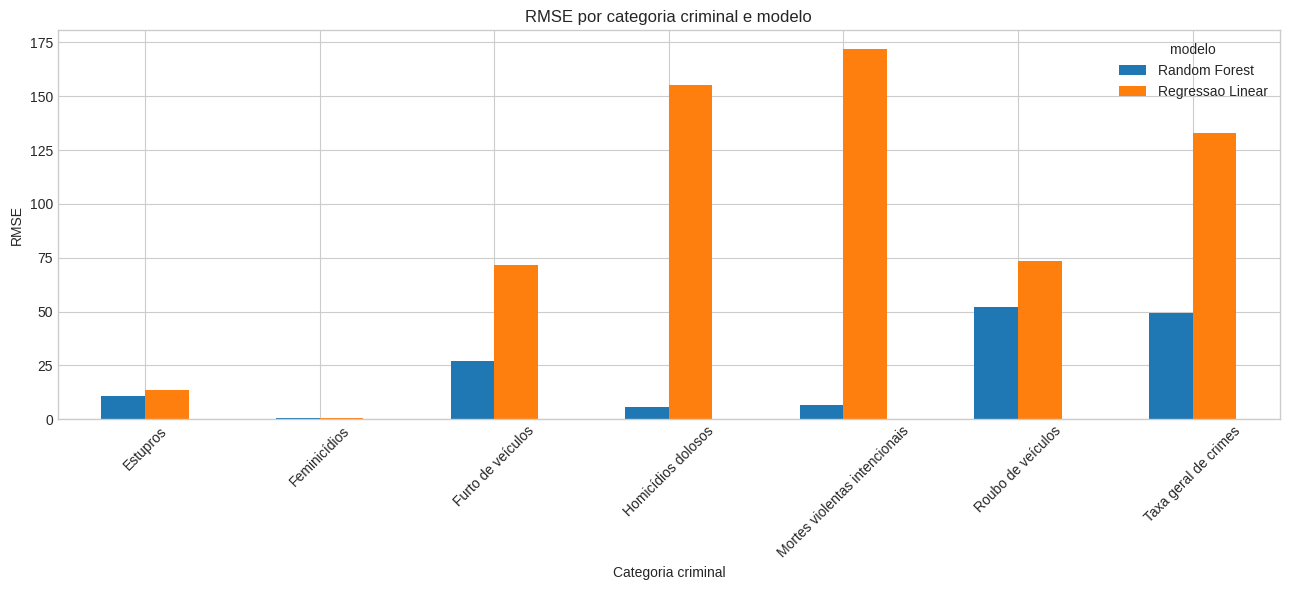

In [13]:
ax = metricas_modelos.pivot(index='target', columns='modelo', values='rmse').plot(
    kind='bar',
    figsize=(13, 6),
    rot=45,
)
ax.set_title('RMSE por categoria criminal e modelo')
ax.set_ylabel('RMSE')
ax.set_xlabel('Categoria criminal')
plt.tight_layout()
plt.show()

## 14. Real vs previsto - melhores modelos

O gráfico abaixo usa apenas o melhor modelo de cada categoria, conforme menor `RMSE`.

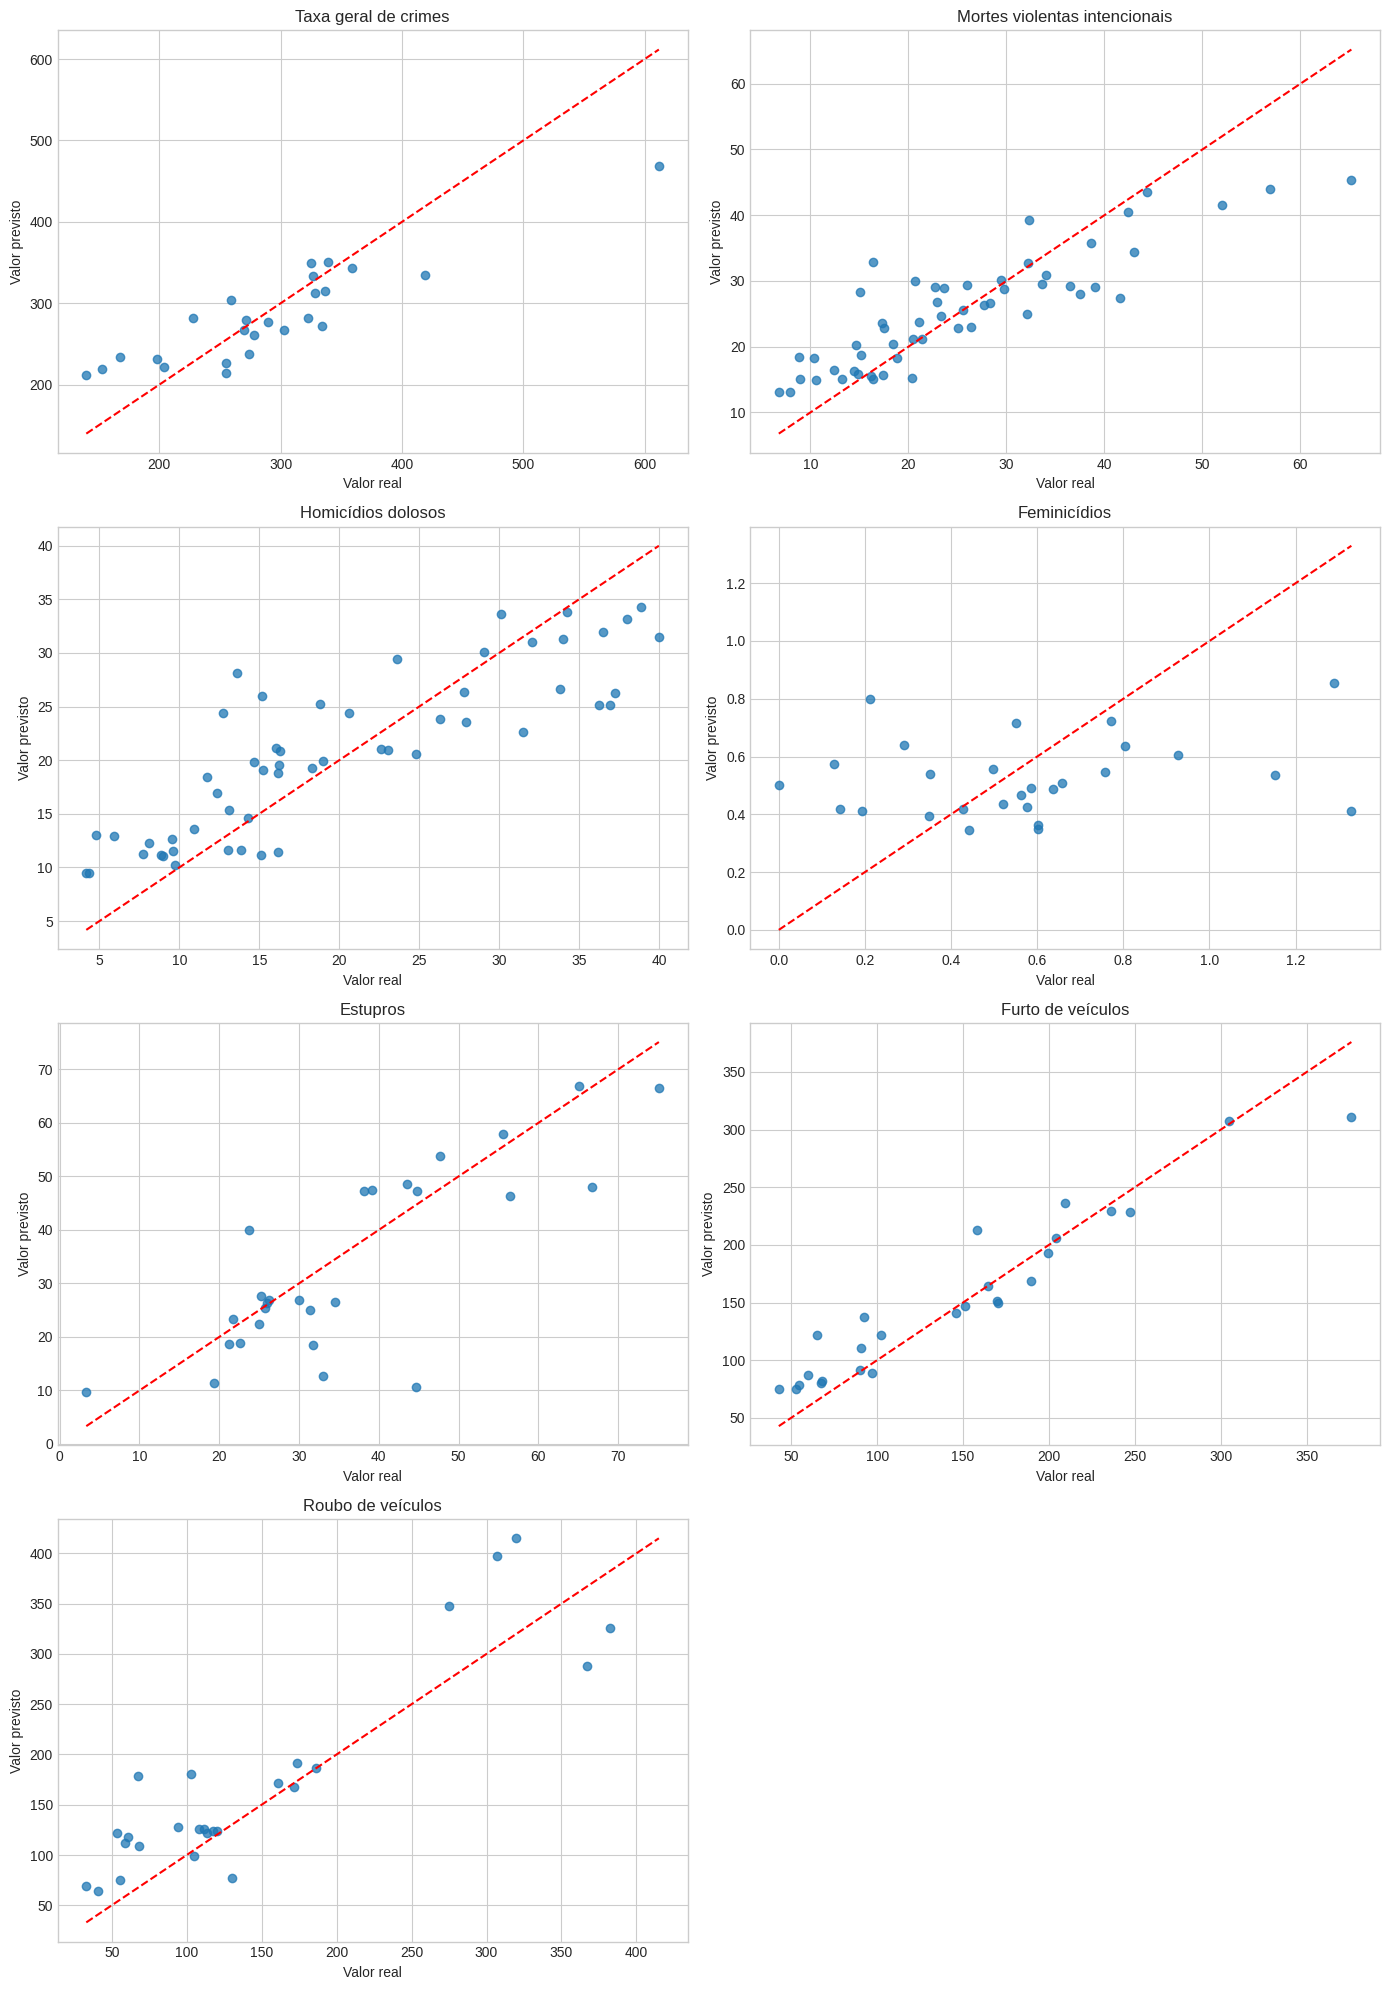

In [14]:
previsoes_melhores = previsoes_modelos.merge(
    melhores_modelos[['target', 'modelo']],
    on=['target', 'modelo'],
    how='inner',
)

targets_plot = list(previsoes_melhores['target'].unique())
qtd_targets = len(targets_plot)
cols = 2
rows = int(np.ceil(qtd_targets / cols))

fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
axes = np.array(axes).reshape(-1)

for ax, target_nome in zip(axes, targets_plot):
    dados_target = previsoes_melhores[previsoes_melhores['target'] == target_nome]
    limite_min = min(dados_target['valor_real'].min(), dados_target['valor_previsto'].min())
    limite_max = max(dados_target['valor_real'].max(), dados_target['valor_previsto'].max())

    ax.scatter(dados_target['valor_real'], dados_target['valor_previsto'], alpha=0.75)
    ax.plot([limite_min, limite_max], [limite_min, limite_max], color='red', linestyle='--')
    ax.set_title(target_nome)
    ax.set_xlabel('Valor real')
    ax.set_ylabel('Valor previsto')

for ax in axes[qtd_targets:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

## 15. Análise de resíduos - melhores modelos

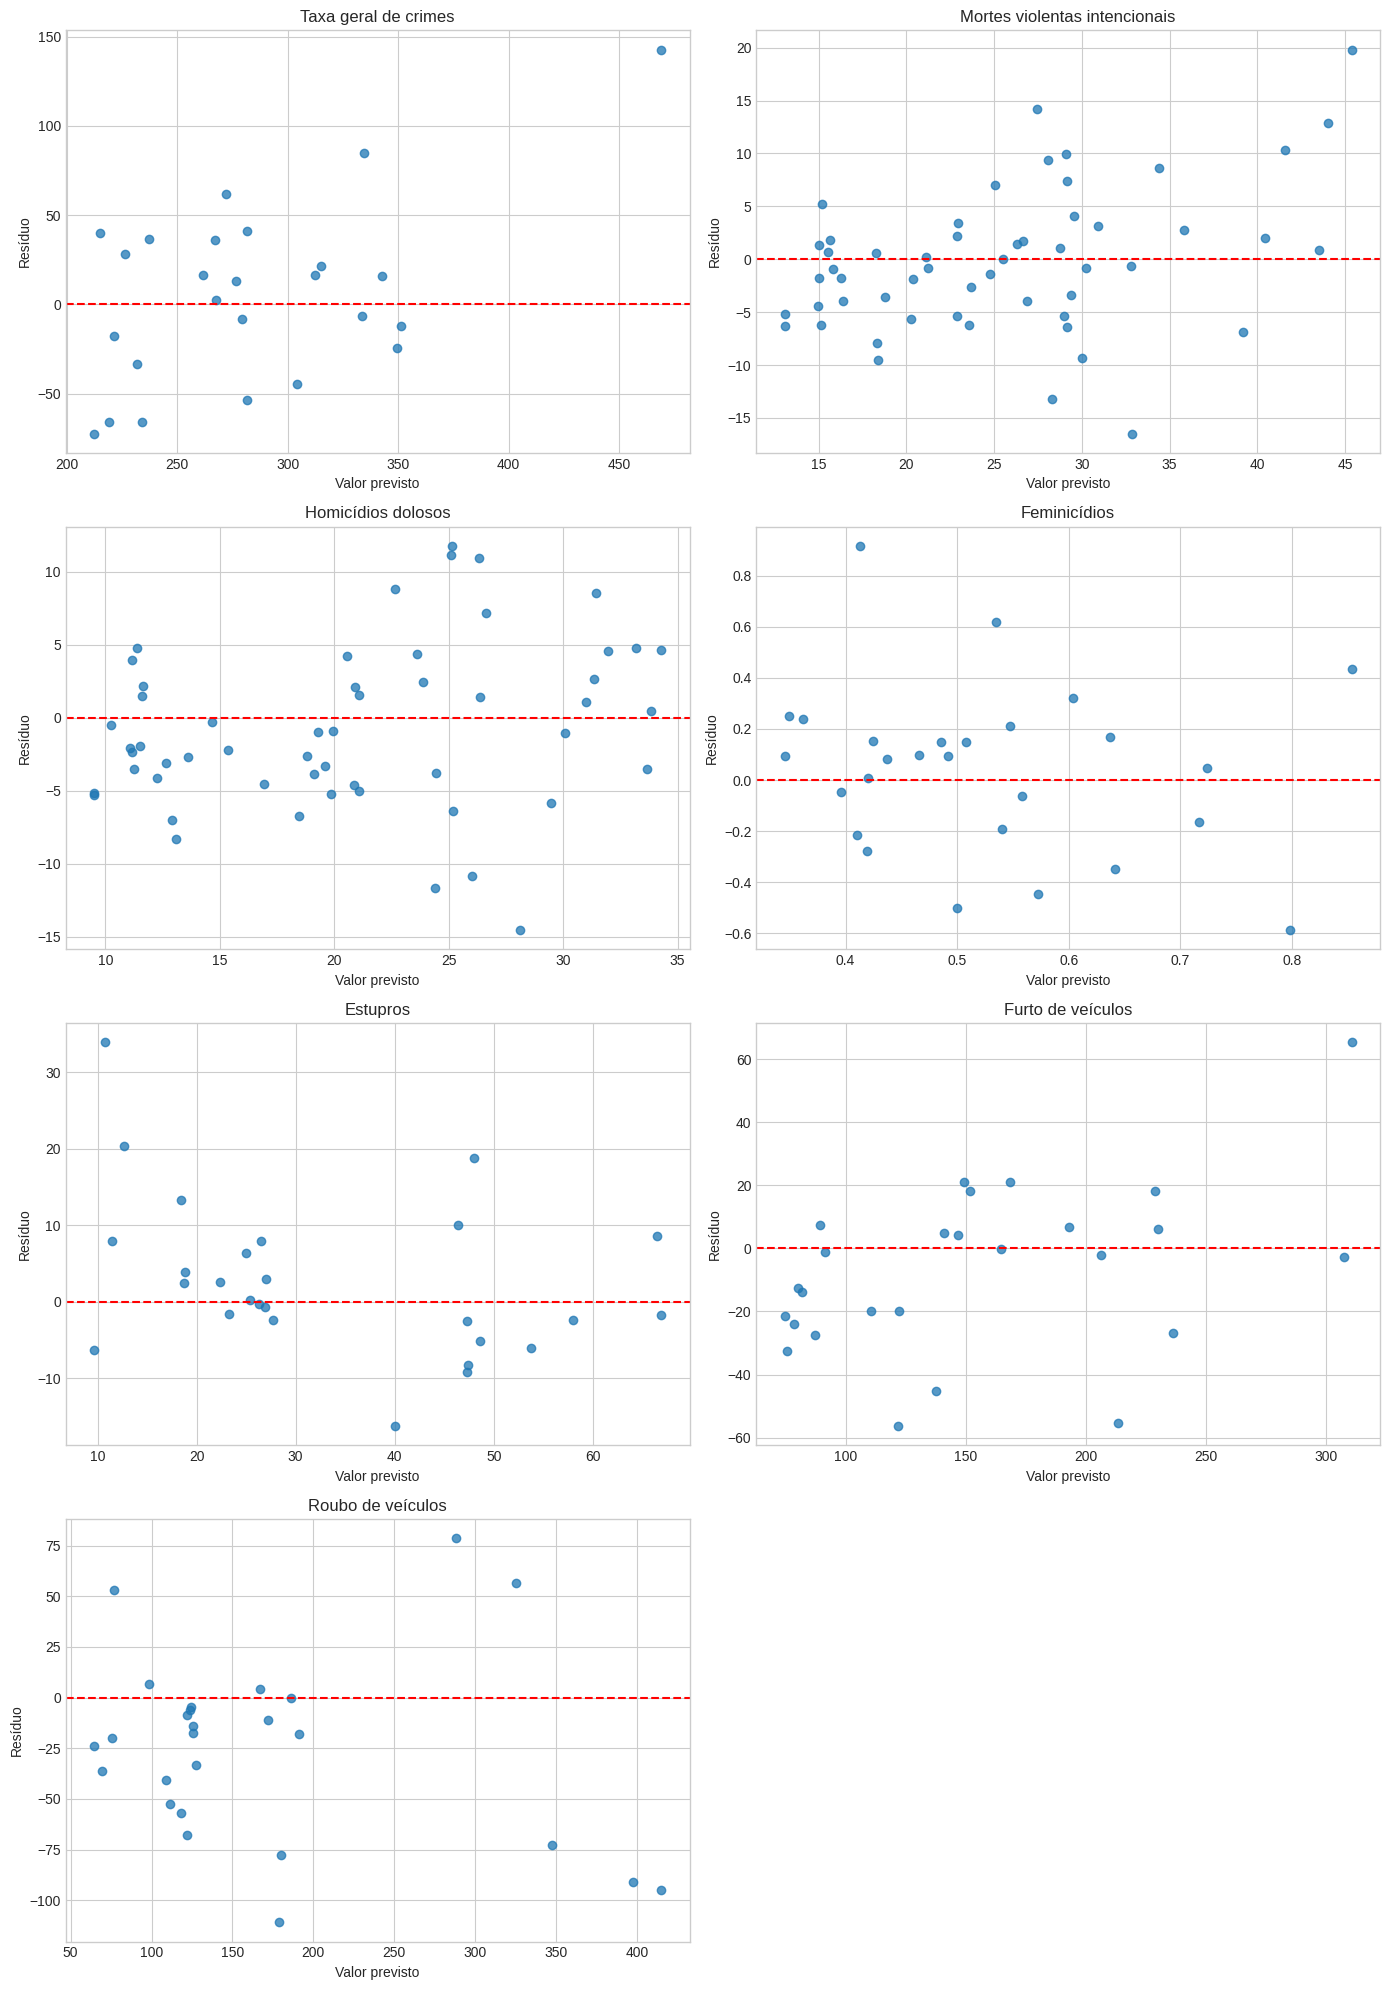

In [15]:
fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
axes = np.array(axes).reshape(-1)

for ax, target_nome in zip(axes, targets_plot):
    dados_target = previsoes_melhores[previsoes_melhores['target'] == target_nome]
    ax.scatter(dados_target['valor_previsto'], dados_target['residuo'], alpha=0.75)
    ax.axhline(0, color='red', linestyle='--')
    ax.set_title(target_nome)
    ax.set_xlabel('Valor previsto')
    ax.set_ylabel('Resíduo')

for ax in axes[qtd_targets:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

## 16. Maiores erros por categoria

In [16]:
previsoes_melhores.sort_values(
    ['target', 'erro_absoluto'],
    ascending=[True, False],
).groupby('target').head(5)

,ano,codigo_municipio,nome_municipio,sigla_uf,nome_regiao,target,modelo,valor_real,valor_previsto,residuo,erro_absoluto
161,2019,1200401,Rio Branco,AC,Norte,Estupros,Random Forest,44.682423,10.737604,33.944819,33.944819
185,2019,5208707,Goiania,GO,Centro-Oeste,Estupros,Random Forest,33.045030,12.681051,20.363979,20.363979
165,2019,1600303,Macapa,AP,Norte,Estupros,Random Forest,66.755807,48.008674,18.747133,18.747133
164,2019,1501402,Belem,PA,Norte,Estupros,Random Forest,23.714700,39.986660,-16.271960,16.271960
173,2019,2704302,Maceio,AL,Nordeste,Estupros,Random Forest,31.699361,18.441995,13.257366,13.257366
141,2024,2211001,Teresina,PI,Nordeste,Feminicídios,Random Forest,1.329428,0.412982,0.916446,0.916446
156,2024,5002704,Campo Grande,MS,Centro-Oeste,Feminicídios,Random Forest,1.152391,0.535210,0.617181,0.617181
136,2024,1400100,Boa Vista,RR,Norte,Feminicídios,Random Forest,0.212689,0.798690,-0.586001,0.586001
138,2024,1600303,Macapa,AP,Norte,Feminicídios,Random Forest,0.000000,0.499958,-0.499958,0.499958
143,2024,2408102,Natal,RN,Nordeste,Feminicídios,Random Forest,0.127329,0.572951,-0.445622,0.445622


## 17. Importância das variáveis - Random Forest

A tabela mostra as variáveis mais importantes no Random Forest para cada categoria modelada.

In [17]:
importancias_rf = importancias_modelos[
    (importancias_modelos['modelo'] == 'Random Forest')
    & (importancias_modelos['tipo_importancia'] == 'feature_importance')
].copy()

importancias_rf.sort_values(['target', 'valor'], ascending=[True, False]).groupby('target').head(8)

,target,modelo,feature,tipo_importancia,valor
126,Estupros,Random Forest,taxa_estupros_100k_lag1,feature_importance,0.905818
127,Estupros,Random Forest,idhm_educacao,feature_importance,0.026167
128,Estupros,Random Forest,populacao_crescimento_pct,feature_importance,0.018088
129,Estupros,Random Forest,idhm_renda,feature_importance,0.010104
130,Estupros,Random Forest,populacao_total,feature_importance,0.009496
131,Estupros,Random Forest,fluxo_preenchido,feature_importance,0.005763
132,Estupros,Random Forest,idhm_longevidade,feature_importance,0.005741
133,Estupros,Random Forest,ideb_preenchido,feature_importance,0.004438
98,Feminicídios,Random Forest,populacao_total,feature_importance,0.219828
99,Feminicídios,Random Forest,idhm_longevidade,feature_importance,0.180682


## 18. Conclusões finais

O objetivo geral do projeto é analisar e prever a criminalidade nas capitais brasileiras de forma ampla, considerando a taxa geral de crimes e recortes por categoria, como roubo/furto de veículos, homicídios, estupros, feminicídios e mortes violentas intencionais.

Nesta versão do notebook, a modelagem foi expandida para seguir esse objetivo. Cada categoria criminal foi tratada como um target próprio, com treinamento separado de **Regressão Linear** e **Random Forest**. Essa decisão é importante porque cada tipo de crime possui escala, comportamento e cobertura histórica diferentes.

O **Random Forest Regressor** apresentou o melhor desempenho em todas as categorias modeladas. Além disso, não gerou previsões negativas nos melhores modelos, o que é essencial porque taxas criminais não podem assumir valores abaixo de zero.

Os melhores resultados por categoria foram:

- Taxa geral de crimes: `RMSE = 49.22`, `R² = 0.72`
- Mortes violentas intencionais: `RMSE = 6.71`, `R² = 0.72`
- Homicídios dolosos: `RMSE = 5.67`, `R² = 0.71`
- Feminicídios: `RMSE = 0.33`, `R² = -0.01`
- Estupros: `RMSE = 10.57`, `R² = 0.58`
- Furto de veículos: `RMSE = 27.05`, `R² = 0.89`
- Roubo de veículos: `RMSE = 51.88`, `R² = 0.73`

A **Regressão Linear** permanece como baseline interpretável, mas teve desempenho inferior ao Random Forest, especialmente nas categorias com comportamento mais não linear. Isso reforça que a relação entre criminalidade, população, IDHM, educação e histórico criminal não é bem capturada por um modelo linear simples.

A interpretação dos resultados deve considerar a cobertura dos dados. Mortes violentas e homicídios conseguiram usar o split pós-pandemia planejado, com treino em `2017-2019` e teste em `2023-2024`. Já categorias como estupros, furto e roubo de veículos precisaram usar split alternativo, pois não há cobertura consistente em nível de capital nos anos pós-pandemia. A taxa geral de crimes também precisou de fallback com anos da pandemia, por falta de série histórica completa após a combinação de todos os indicadores.

Com base nesses resultados, o **Random Forest é o principal candidato para a modelagem preditiva por categoria criminal**. Ainda assim, os modelos devem ser reavaliados quando novos anos e novas fontes forem adicionados, principalmente para melhorar a cobertura da taxa geral e das categorias patrimoniais e sexuais.